<a href="https://colab.research.google.com/github/NavyaYadagiri/Big-Data-/blob/main/IDS_561_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#importing the required libraries

import pandas as pd
import numpy as np
import pyspark
from pyspark.sql import SparkSession
from pyspark import SparkContext, SparkConf
from datetime import datetime
import pytz
import string
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('seaborn-whitegrid')
import numpy as np
import findspark
from pyspark.sql.types import IntegerType
from pyspark.ml.feature import VectorAssembler
findspark.init()

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 281.4 MB 45 kB/s 
     |████████████████████████████████| 199 kB 63.5 MB/s 
  Created wheel for pyspark: filename=pyspark-3.3.1-py2.py3-none-any.whl size=281845512 sha256=b08ce4c72771e5300e5e91c815ffda8148ab62f9f1527c618ebba8b465dc7249
  Stored in directory: /root/.cache/pip/wheels/42/59/f5/79a5bf931714dcd201b26025347785f087370a10a3329a899c
Successfully built pyspark


In [ ]:
pip install findspark

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
# initiating spark session

session = SparkSession.builder.getOrCreate()
context = SparkContext.getOrCreate()

In [ ]:
# importing data as csv and into the spark session

df = session.read.csv('big data.csv',header=True)
df_pd = pd.read_csv('big data.csv')

In [ ]:
df.show(5)

+-------+----------+----+-----+------------+-----------+---------------+-----------------+--------+-----------------+-----------------+------+------------------+---------------+----+----------------+------------+--------+---------+--------+----------+---------+-------+------------+--------+---------+---------+-----------------+--------+----------------+-------------------+--------+--------+-------------+-------------+---------+--------------+-------------------+
|    _c0|Unnamed: 0|YEAR|MONTH|DAY_OF_MONTH|DAY_OF_WEEK|        FL_DATE|OP_UNIQUE_CARRIER|TAIL_NUM|OP_CARRIER_FL_NUM|ORIGIN_AIRPORT_ID|ORIGIN|  ORIGIN_CITY_NAME|DEST_AIRPORT_ID|DEST|  DEST_CITY_NAME|CRS_DEP_TIME|DEP_TIME|DEP_DELAY|TAXI_OUT|WHEELS_OFF|WHEELS_ON|TAXI_IN|CRS_ARR_TIME|ARR_TIME|ARR_DELAY|CANCELLED|CANCELLATION_CODE|DIVERTED|CRS_ELAPSED_TIME|ACTUAL_ELAPSED_TIME|AIR_TIME|DISTANCE|CARRIER_DELAY|WEATHER_DELAY|NAS_DELAY|SECURITY_DELAY|LATE_AIRCRAFT_DELAY|
+-------+----------+----+-----+------------+-----------+----------

## Data Exploration :

In [ ]:
print('The dataset has {} rows and {} columns'.format(df.count(),len(df.columns)))

The dataset has 110699 rows and 38 columns


In [ ]:
# adding data into spark view for sql querying

df.createOrReplaceTempView('df')

In [ ]:
# identify all columns of the dataset

print(df.columns)

['_c0', 'Unnamed: 0', 'YEAR', 'MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'FL_DATE', 'OP_UNIQUE_CARRIER', 'TAIL_NUM', 'OP_CARRIER_FL_NUM', 'ORIGIN_AIRPORT_ID', 'ORIGIN', 'ORIGIN_CITY_NAME', 'DEST_AIRPORT_ID', 'DEST', 'DEST_CITY_NAME', 'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY', 'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME', 'ACTUAL_ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY']


In [ ]:
# select only relevant columns

df = df.select('ORIGIN_CITY_NAME', 'DEST_CITY_NAME','YEAR','DAY_OF_MONTH','MONTH','OP_UNIQUE_CARRIER','ORIGIN_CITY_NAME','DEST_CITY_NAME','CRS_DEP_TIME','DEP_TIME','DEP_DELAY','CRS_ARR_TIME','ARR_TIME','ARR_DELAY','CANCELLED','DIVERTED','CRS_ELAPSED_TIME','AIR_TIME','DISTANCE','DEST','ORIGIN')

### Below are a couple of SQL queries we used to explore the data

In [ ]:
# just to check how the sql query is performing
query = "SELECT ORIGIN, DEST,COUNT(*) AS FLIGHTS FROM df group by ORIGIN, DEST ORDER BY COUNT(*) DESC LIMIT 10"

# Get the first 10 rows of flights
df_new = session.sql(query)

# Show the results
df_new.show()

+------+----+-------+
|ORIGIN|DEST|FLIGHTS|
+------+----+-------+
|   LAX| SFO|    210|
|   SFO| LAX|    201|
|   LAX| LAS|    161|
|   SEA| LAX|    159|
|   LAS| LAX|    157|
|   LAX| DEN|    152|
|   ORD| LGA|    151|
|   OGG| HNL|    149|
|   DEN| PHX|    145|
|   JFK| LAX|    144|
+------+----+-------+



In [ ]:
# Show top 10 origin cities with most total distance covered

query = "SELECT ORIGIN_CITY_NAME,SUM(DISTANCE) AS TOTAL_DISTANCE FROM df GROUP BY ORIGIN_CITY_NAME ORDER BY SUM(DISTANCE) DESC LIMIT 10"

# Run the query

distance = session.sql(query)

distance.show()

+--------------------+--------------+
|    ORIGIN_CITY_NAME|TOTAL_DISTANCE|
+--------------------+--------------+
|         Chicago, IL|     4458668.0|
|Dallas/Fort Worth...|     4169465.0|
|          Denver, CO|     3932962.0|
|         Atlanta, GA|     3825618.0|
|     Los Angeles, CA|     3799450.0|
|        New York, NY|     3099247.0|
|         Seattle, WA|     3083508.0|
|         Phoenix, AZ|     2756558.0|
|         Houston, TX|     2612297.0|
|       Las Vegas, NV|     2485628.0|
+--------------------+--------------+



In [ ]:
# Average distance covered by month

query = "SELECT MONTH,SUM(DISTANCE)/COUNT(*) AS AVERAGE_DISTANCE FROM df GROUP BY MONTH ORDER BY SUM(DISTANCE) DESC"

# Run the query

distance = session.sql(query)

distance.show()

+-----+-----------------+
|MONTH| AVERAGE_DISTANCE|
+-----+-----------------+
|    3|811.7795632212433|
|    1|797.4105894764605|
|    2|802.7683070729506|
|   11|797.7502497502497|
|    8|756.3042745841229|
|    7|768.8029445073613|
|    4|734.6388642413488|
|   12|779.4217554388597|
|    9|764.1151840490797|
|   10|767.4848484848485|
|    6|748.4335187511215|
|    5|720.9080333625988|
+-----+-----------------+



In [ ]:
# Average distance covered by Origin

query = "SELECT ORIGIN_CITY_NAME,SUM(DISTANCE)/COUNT(*) AS AVERAGE_DISTANCE FROM df GROUP BY ORIGIN_CITY_NAME ORDER BY SUM(DISTANCE)/COUNT(*) DESC LIMIT 10"

# Run the query

distance = session.sql(query)

distance.show()

+--------------------+------------------+
|    ORIGIN_CITY_NAME|  AVERAGE_DISTANCE|
+--------------------+------------------+
|       Pago Pago, TT|            2599.0|
|            Guam, TT|            1965.0|
|        San Juan, PR|1395.3063063063064|
|       St. Cloud, MN|            1306.0|
|           Ponce, PR|            1288.5|
|     Los Angeles, CA|1261.8565260710727|
|         Seattle, WA|1230.4501197126895|
|Charlotte Amalie, VI|1215.4358974358975|
|        Rockford, IL| 1194.764705882353|
|   Christiansted, VI|1166.9444444444443|
+--------------------+------------------+



## Data Visualization :

In [ ]:
# check for null values in our dataset

df_pd.isna().sum().sort_values(ascending=False)

CANCELLATION_CODE      103692
LATE_AIRCRAFT_DELAY    100499
NAS_DELAY              100499
WEATHER_DELAY          100499
CARRIER_DELAY          100499
SECURITY_DELAY         100499
AIR_TIME                 7167
ACTUAL_ELAPSED_TIME      7167
ARR_DELAY                7167
TAXI_IN                  7019
WHEELS_ON                7019
ARR_TIME                 7019
TAXI_OUT                 6985
WHEELS_OFF               6985
DEP_DELAY                6966
DEP_TIME                 6961
TAIL_NUM                 3861
CRS_ARR_TIME                0
ORIGIN_AIRPORT_ID           0
Unnamed: 0.1                0
YEAR                        0
MONTH                       0
DAY_OF_MONTH                0
DAY_OF_WEEK                 0
FL_DATE                     0
OP_UNIQUE_CARRIER           0
OP_CARRIER_FL_NUM           0
ORIGIN                      0
CANCELLED                   0
ORIGIN_CITY_NAME            0
DEST_AIRPORT_ID             0
DEST                        0
DEST_CITY_NAME              0
CRS_DEP_TI

In [ ]:
# dropping null values

df_new = df_pd.dropna()

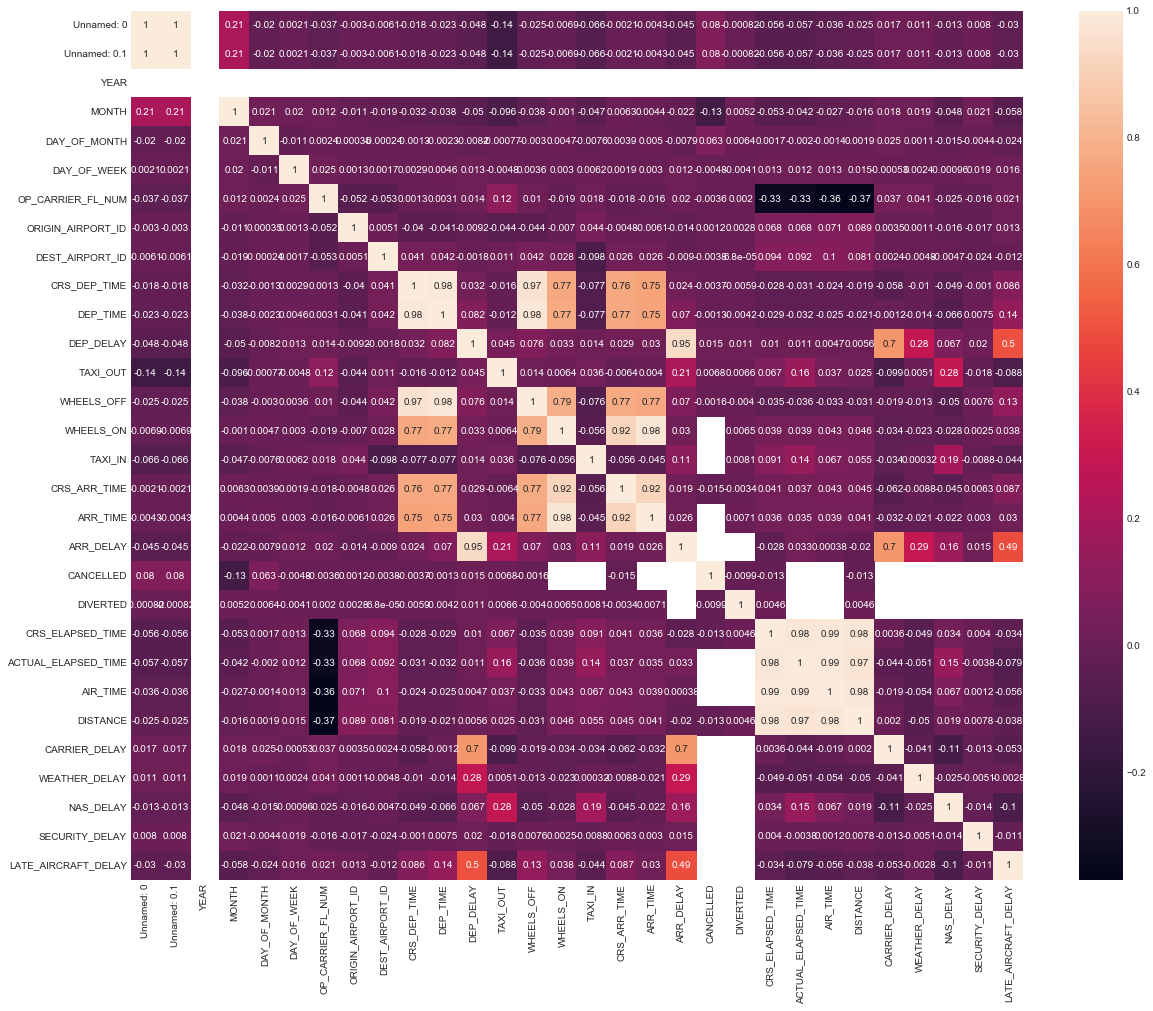

In [ ]:
# plotting correlation

import seaborn as sb
import matplotlib.pyplot as plt
pd.set_option('display.max_columns',500)
%matplotlib inline

plt.figure(figsize=(20, 16))
sb.heatmap(df_pd.corr(),annot = True)

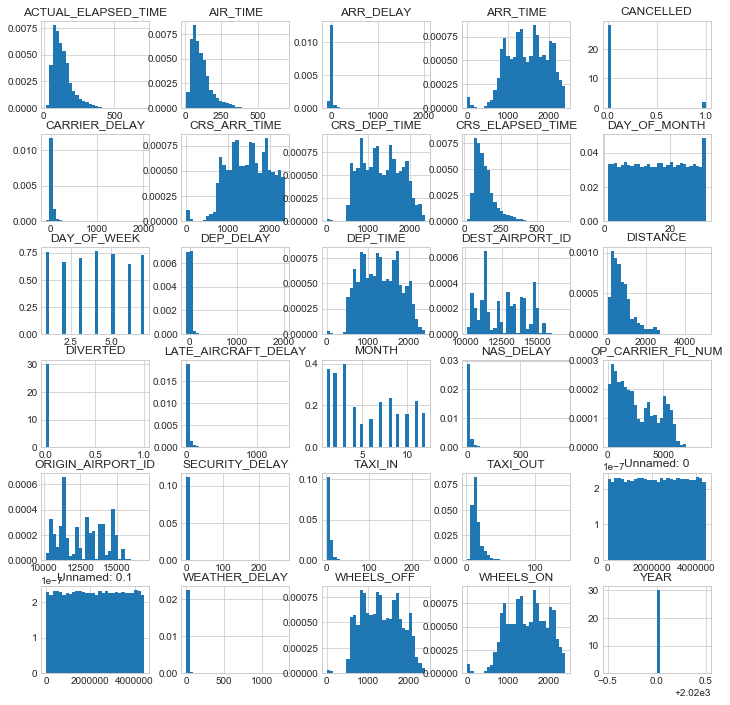

In [ ]:
# Visualize the variable distribution with histograms

df_pd.hist(bins=30, figsize=(12,12), density=True)
plt.show()

In [ ]:
# dropping unnecessary columns from our dataset

df_2 = df_pd.drop(['Unnamed: 0','Unnamed: 0.1','YEAR','MONTH', 'DAY_OF_WEEK', 'DAY_OF_MONTH', 'FL_DATE', 'ORIGIN_AIRPORT_ID', 'OP_UNIQUE_CARRIER',
       'TAIL_NUM', 'OP_CARRIER_FL_NUM', 'ORIGIN', 'ORIGIN_CITY_NAME', 'DEST', 'DEST_AIRPORT_ID',
       'DEST_CITY_NAME', 'CRS_DEP_TIME', 'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'CANCELLATION_CODE',
              'CRS_ELAPSED_TIME', 'ACTUAL_ELAPSED_TIME', 'AIR_TIME', 'DISTANCE','NAS_DELAY'],axis=1)

In [ ]:
df_2.head()

,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,ARR_TIME,ARR_DELAY,CANCELLED,DIVERTED,CARRIER_DELAY,WEATHER_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
0,859.0,-6.0,15.0,914.0,1021.0,-15.0,0,0,NaN,NaN,NaN,NaN
1,1034.0,-3.0,17.0,1051.0,1225.0,-13.0,0,0,NaN,NaN,NaN,NaN
2,2056.0,-3.0,38.0,2134.0,2142.0,-10.0,0,0,NaN,NaN,NaN,NaN
3,1524.0,-1.0,18.0,1542.0,1703.0,-2.0,0,0,NaN,NaN,NaN,NaN
4,1429.0,9.0,10.0,1439.0,1656.0,-5.0,0,0,NaN,NaN,NaN,NaN


In [ ]:
df_2.shape

(110699, 12)

In [ ]:
# replacing nan values with 0

df_2.replace(np.nan, 0,inplace = True)


In [ ]:
# now check again for null values, there shouldn't be any

df_2.isna().sum().sort_values(ascending=False)

LATE_AIRCRAFT_DELAY    0
SECURITY_DELAY         0
WEATHER_DELAY          0
CARRIER_DELAY          0
DIVERTED               0
CANCELLED              0
ARR_DELAY              0
ARR_TIME               0
WHEELS_OFF             0
TAXI_OUT               0
DEP_DELAY              0
DEP_TIME               0
dtype: int64

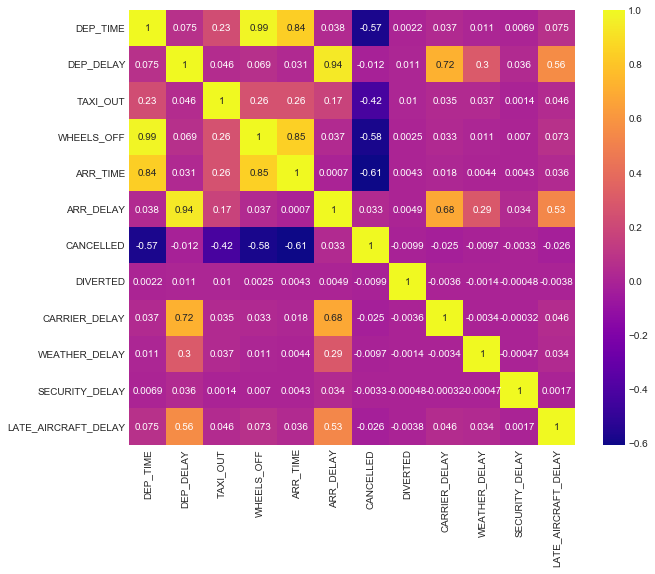

In [ ]:
# Check for Corelation between selected Features

plt.figure(figsize=(10, 8))
sb.heatmap(df_2.corr(),yticklabels=True,cbar=True,annot=True,cmap='plasma')

## Preparing the data :

In [ ]:
df_new = df_2.replace(np.nan, 0)

In [ ]:
df_new = df_new.dropna()

In [ ]:
# if the carrier delay is greater than 0 then assign a label 1 else 0

cols = df_new.columns
df_new[df_new[cols] <= 0] = 0
df_new[df_new[cols] > 0] = 1

In [ ]:
# rename the target variable as Label for easier understanding

df_new = df_new.rename(columns = {'CARRIER_DELAY' : 'Label'})

In [ ]:
# import the dataset into spark

spark_df = session.createDataFrame(df_new)

In [ ]:
# convert the numeric columns to integer type

for i in spark_df.columns :
    data_df = spark_df.withColumn(i, spark_df[i].cast(IntegerType()))

In [ ]:
# assemble all the columns into a vector matrix

feature_list = []
for col in data_df.columns:
    if col == 'Label':
        continue
    else:
        feature_list.append(col)
assembler = VectorAssembler(inputCols=feature_list, outputCol="features")

In [ ]:
df = assembler.transform(data_df)

In [ ]:
# split the dataset into test and train

train, test = df.randomSplit([0.7, 0.3], seed = 10)

## Model Building & Evaluation
We will use ensemble modeling approach and compare different models for higher performance. <br>
1) Logistic Regression <br>2) Random Forrest <br>3) Decision Tree
<br> 4) Gradient Boosting


### 1.) Logistic Regression

In [ ]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(featuresCol = 'features', labelCol = 'Label', maxIter = 5)
lrModel = lr.fit(train)
predictions1 = lrModel.transform(test)

In [ ]:
predictions1.createOrReplaceTempView('predictions1')

In [ ]:
# Write the query

query1 = "SELECT sum(case when prediction = Label then 1 end)*100/count(prediction) as Logistic_Regression_Accuracy FROM predictions1"

# Run the query

q1 = session.sql(query1)
q1.show()

+----------------------------+
|Logistic_Regression_Accuracy|
+----------------------------+
|        92.97801420574249...|
+----------------------------+



### 2.) Random Forest :

In [ ]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(featuresCol = 'features', labelCol = 'Label')
rfModel = rf.fit(train)
predictions2 = rfModel.transform(test)

In [ ]:
predictions2.createOrReplaceTempView('predictions2')

In [ ]:
# Write the query

query2 = "SELECT sum(case when prediction = Label then 1 end)*100/count(prediction) as Random_Forest_Accuracy FROM predictions2"

# Run the query

q2 = session.sql(query2)
q2.show()

+----------------------+
|Random_Forest_Accuracy|
+----------------------+
|  94.02699693011497...|
+----------------------+



### 3.) Decision Tree :

In [ ]:
from pyspark.ml.classification import DecisionTreeClassifier

dt = DecisionTreeClassifier(labelCol="Label", featuresCol="features")
dtModel = dt.fit(train)
predictions3 = dtModel.transform(test)

In [ ]:
# create a temp view for sql queries

predictions3.createOrReplaceTempView('predictions3')

In [ ]:
# Write the query

query3 = "SELECT sum(case when prediction = Label then 1 end)*100/count(prediction) as Decision_Tree_Accuracy FROM predictions3"

# Run the query

q3 = session.sql(query3)
q3.show()

+----------------------+
|Decision_Tree_Accuracy|
+----------------------+
|  92.69192800818636...|
+----------------------+



### 4.) Gradient Classifier :

In [ ]:
from pyspark.ml.classification import GBTClassifier

gbt = GBTClassifier(labelCol="Label", featuresCol="features", maxIter=10)
gtbModel = gbt.fit(train)
predictions4 = gtbModel.transform(test)

In [ ]:
# create a temp view for sql queries

predictions4.createOrReplaceTempView('predictions4')

In [ ]:
# Write the query

query4 = "SELECT sum(case when prediction = Label then 1 end)*100/count(prediction) as Gradient_Boost_Accuracy FROM predictions4"

# Run the query

q4 = session.sql(query4)
q4.show()

+-----------------------+
|Gradient_Boost_Accuracy|
+-----------------------+
|   93.20688316378739...|
+-----------------------+

